
# Persona Cross-Model Analysis

Reads persona accuracy CSVs for four models (kimi, gemini, claude-sonnet, claude-opus) and surfaces cross-model patterns: averages, variability, personalization lift, and rank correlations.


In [24]:
import io
import pandas as pd
from pathlib import Path

In [25]:

BASE = Path('.')
files = {
    'kimi': BASE / 'kimi-k2-0905-preview-FC' / 'persona_accuracy.csv',
    'gemini': BASE / 'gemini-3-flash-FC' / 'persona_accuracy.csv',
    'sonnet': BASE / 'claude-sonnet-4-5-20250929-FC' / 'persona_accuracy.csv',
    'opus': BASE / 'claude-opus-4-5-20251101-FC' / 'persona_accuracy.csv',
}


def read_persona_block(path: Path) -> pd.DataFrame:
    lines = path.read_text().splitlines()
    try:
        blank = lines.index('')
    except ValueError:
        blank = len(lines)
    block = '\n'.join(lines[:blank])
    df = pd.read_csv(io.StringIO(block))
    df = df[df['persona'].str.contains('/')].copy()
    df[['setting', 'persona_name']] = df['persona'].str.split('/', n=1, expand=True)
    return df[['persona_name', 'setting', 'accuracy', 'total_count']]

frames = {m: read_persona_block(p) for m, p in files.items()}
common = set.intersection(*[set(df['persona_name']) for df in frames.values()])
rows = []
for model, df in frames.items():
    rows.append(df[df['persona_name'].isin(common)].assign(model=model))
tidy = pd.concat(rows, ignore_index=True)
print('Models:', list(files))
print('Personas per model:', {m: len(f['persona_name'].unique()) for m, f in frames.items()})
print('Common personas:', len(common))


Models: ['kimi', 'gemini', 'sonnet', 'opus']
Personas per model: {'kimi': 31, 'gemini': 31, 'sonnet': 31, 'opus': 31}
Common personas: 31


In [26]:

personalization = tidy[tidy['setting'] == 'personalization'].pivot(index='persona_name', columns='model', values='accuracy')
no_personalization = tidy[tidy['setting'] == 'no_personalization'].pivot(index='persona_name', columns='model', values='accuracy')

lift = personalization - no_personalization
lift_long = lift.reset_index().melt(id_vars='persona_name', var_name='model', value_name='lift')
lift_stats = lift_long.groupby('persona_name').agg(
    mean_lift=('lift', 'mean'),
    std_lift=('lift', 'std'),
    pos_models=('lift', lambda s: (s > 0).sum()),
    neg_models=('lift', lambda s: (s < 0).sum()),
).reset_index()

print('\nTop 5 avg accuracy (personalization)')
display(personalization.mean(axis=1).sort_values(ascending=False).head(5))
print('\nBottom 5 avg accuracy (personalization)')
display(personalization.mean(axis=1).sort_values(ascending=True).head(5))

print('\nTop 5 avg accuracy (no_personalization)')
display(no_personalization.mean(axis=1).sort_values(ascending=False).head(5))
print('\nBottom 5 avg accuracy (no_personalization)')
display(no_personalization.mean(axis=1).sort_values(ascending=True).head(5))

print('\nHighest std across models (personalization)')
display(personalization.std(axis=1).sort_values(ascending=False).head(5))
print('\nLowest std across models (personalization)')
display(personalization.std(axis=1).sort_values(ascending=True).head(5))

print('\nPersonalization lift mean/std (top positive)')
display(lift_stats.sort_values('mean_lift', ascending=False))
print('\nPersonalization lift mean/std (most negative)')
display(lift_stats.sort_values('mean_lift', ascending=True))

# print('\nRank correlations (Spearman) personalization')
# display(personalization.corr(method='spearman'))
# print('\nRank correlations (Spearman) no_personalization')
# display(no_personalization.corr(method='spearman'))
# print('\nRank correlations (Spearman) lift')
# display(lift.corr(method='spearman'))



Top 5 avg accuracy (personalization)


persona_name
tool_high               0.761925
info_collect_upfront    0.716575
info_collect_gradual    0.712075
each_confirmation       0.708025
presentation_layered    0.704425
dtype: float64


Bottom 5 avg accuracy (personalization)


persona_name
tool_switch_low_agency      0.473225
error_retry_escalation      0.479150
tool_initiative_reactive    0.509050
param_high                  0.509925
tool_invocation_multiple    0.511300
dtype: float64


Top 5 avg accuracy (no_personalization)


...

persona_name
tool_invocation_multiple    0.020833
param_low                   0.036183
tool_abortion_stop          0.046535
tool_invocation_single      0.046839
chain_parallel              0.050852
dtype: float64


Personalization lift mean/std (top positive)


,persona_name,mean_lift,std_lift,pos_models,neg_models
11,info_collect_upfront,0.082925,0.071939,4,0
17,silent,0.054425,0.086061,3,1
1,chain_sequential,0.051875,0.115011,2,2
3,disambiguation_gradual,0.047400,0.035126,3,0
27,tool_low,0.038400,0.069124,3,1
10,info_collect_gradual,0.037275,0.074513,3,1
26,tool_invocation_single,0.037175,0.102171,2,2
5,each_confirmation,0.036700,0.100181,3,1
8,error_retry_escalation,0.036450,0.072900,1,0
12,param_high,0.034725,0.034643,3,1



Personalization lift mean/std (most negative)


,persona_name,mean_lift,std_lift,pos_models,neg_models
25,tool_invocation_multiple,-0.039550,0.070392,1,3
21,tool_abortion_stop,-0.026375,0.079695,2,2
2,confirmation_batch,-0.023525,0.096703,2,2
30,tool_switch_low_agency,-0.014525,0.083640,2,2
15,presentation_compact,-0.012625,0.131221,3,1
13,param_low,-0.011250,0.101067,1,3
19,source_low,-0.008275,0.047059,1,3
24,tool_initiative_reactive,-0.002825,0.010371,2,2
16,presentation_layered,-0.002625,0.045596,2,2
22,tool_high,0.001625,0.055033,3,1


In [27]:
print('\nPersonalization lift mean/std (top positive)')
display(lift_stats.sort_values('pos_models', ascending=False))





Personalization lift mean/std (top positive)


,persona_name,mean_lift,std_lift,pos_models,neg_models
11,info_collect_upfront,0.082925,0.071939,4,0
15,presentation_compact,-0.012625,0.131221,3,1
28,tool_medium,0.028025,0.107954,3,1
22,tool_high,0.001625,0.055033,3,1
17,silent,0.054425,0.086061,3,1
14,param_medium,0.021150,0.044518,3,1
12,param_high,0.034725,0.034643,3,1
27,tool_low,0.038400,0.069124,3,1
10,info_collect_gradual,0.037275,0.074513,3,1
7,error_discovery_detail,0.013425,0.056321,3,1


In [28]:
# 汇总各模型 no_personalization / personalization 总分
from io import StringIO

def load_total_rows(csv_path):
    lines = Path(csv_path).read_text().splitlines()
    first_block = []
    for line in lines:
        if not line.strip():
            break
        first_block.append(line)
    df = pd.read_csv(StringIO('\n'.join(first_block)))
    total_no = df.loc[df['persona'] == 'no_personalization', 'accuracy'].iloc[0]
    total_yes = df.loc[df['persona'] == 'personalization', 'accuracy'].iloc[0]
    return total_no, total_yes

csv_files = [
    ('claude-opus-4-5-20251101-FC', BASE / 'claude-opus-4-5-20251101-FC' / 'persona_accuracy.csv'),
    ('kimi-k2-0905-preview-FC', BASE / 'kimi-k2-0905-preview-FC' / 'persona_accuracy.csv'),
    ('gemini-3-flash-FC', BASE / 'gemini-3-flash-FC' / 'persona_accuracy.csv'),
    ('claude-sonnet-4-5-20250929-FC', BASE / 'claude-sonnet-4-5-20250929-FC' / 'persona_accuracy.csv'),
]

rows = []
for model_name, path in csv_files:
    no_personalization, personalization = load_total_rows(path)
    rows.append({
        'model': model_name,
        'no_personalization': no_personalization,
        'personalization': personalization,
    })

total_df = pd.DataFrame(rows)



In [29]:
print(total_df)

                           model  no_personalization  personalization
0    claude-opus-4-5-20251101-FC              0.6686           0.6867
1        kimi-k2-0905-preview-FC              0.6051           0.6312
2              gemini-3-flash-FC              0.4967           0.5075
3  claude-sonnet-4-5-20250929-FC              0.6207           0.6256


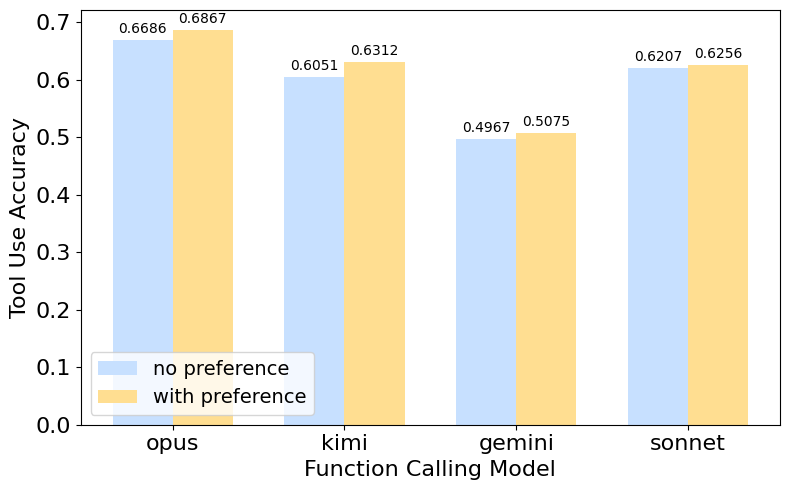

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# 只保留模型名字的核心部分
def short_model_name(full_name):
    if "opus" in full_name:
        return "opus"
    elif "kimi" in full_name:
        return "kimi"
    elif "gemini" in full_name:
        return "gemini"
    elif "sonnet" in full_name:
        return "sonnet"
    else:
        return full_name

models = total_df['model'].apply(short_model_name)
no_personalization = total_df['no_personalization']
personalization = total_df['personalization']

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(
    x - width/2, 
    no_personalization, 
    width, 
    label='no preference', 
    color='#c7e0ff'
)
rects2 = ax.bar(
    x + width/2, 
    personalization, 
    width, 
    label='with preference', 
    color='#ffde91'
)

ax.set_ylabel('Tool Use Accuracy', fontsize=16)
ax.set_xlabel('Function Calling Model', fontsize=16)
# ax.set_title('Accuracy by Model and Personalization', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=0, fontsize=14)   # 名字正过来，不要斜着
ax.legend(fontsize=14)

# Set y-axis ticklabel font size
ax.tick_params(axis='y', labelsize=16)
# Set x-axis ticklabel font size (already done above, but to ensure both axes included)
ax.tick_params(axis='x', labelsize=16)

# Optional: add value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()
